# Lecture: Quantum Computing in Finance
## Topic: Solving Index Replication via Quantum Annealing

**Instructor:** Petar Nikolov  
**Date:** June 2026  
**Objective:** To understand how a combinatorial optimization problem (Index Replication) can be mapped to a Quadratic Unconstrained Binary Optimization (QUBO) format suitable 
for Quantum Annealers.

---

### 1. Introduction to Index Replication
In quantitative finance, **Index Replication** is the process of constructing a portfolio of individual stocks that mimics the performance of a benchmark index (like the S&P 
500).

**The Challenge:**
If we were allowed continuous weights ($w_i \in [0, 1]$), this would be a simple Quadratic Programming problem. However, in real-world trading:
1. **Lot Sizes:** You can only buy stocks in discrete units.
2. **Transaction Costs:** Moving from one portfolio to another has costs.
3. **Cardinality Constraints:** Large portfolios are expensive to manage; we want to select a *subset* of $K$ stocks from $N$ available stocks.

When we introduce these constraints, the problem becomes **NP-Hard**. This is where **Quantum Annealing (QA)** enters the stage.

---

### 2. The Mathematical Problem
Let:
- $r_i$: The return of stock $i$.
- $R_{target}$: The target return of the index we want to replicate.
- $x_i \in \{0, 1\}$: A binary variable where $1$ means we include stock $i$ in our subset, and $0$ means we do not.

**Our Goal:** Minimize the tracking error (the difference between our portfolio return and the target).

$$ \text{Minimize } f(x) = \left( \sum_{i=1}^{n} r_i x_i - R_{target} \right)^2 $$

### 3. Mapping to QUBO
Quantum Annealers solve problems in the form of **QUBO**:
$$ H(x) = \sum_{i} Q_{ii} x_i + \sum_{i < j} Q_{ij} x_i x_j $$

Let's expand our objective function:
$$ f(x) = \left( \sum r_i x_i - R_{target} \right)^2 $$
$$ f(x) = (\sum r_i x_i)^2 - 2 R_{target}(\sum r_i x_i) + R_{target}^2 $$

Expanding the square:
$$ f(x) = \sum_{i} (r_i^2) x_i^2 + 2\sum_{i < j} (r_i r_j) x_i x_j - 2R_{target}\sum_{i} r_i x_i + \text{const} $$

Since $x_i$ is binary, $x_i^2 = x_i$. We can group the terms:
$$ f(x) = \sum_{i} (r_i^2 - 2R_{target}r_i) x_i + \sum_{i < j} (2r_i r_j) x_i x_j $$

This is exactly the QUBO form! Each $Q_{ii}$ and $Q_{ij}$ can be mapped to a matrix for the Quantum Annealer.


## From a Continuous Portfolio to a Binary Selection — and what "Tracking Error" means

The cell above already wrote down the objective; this section unpacks the two
ideas hiding inside it: **what tracking error is**, and **how a continuous
portfolio problem becomes the binary one our QUBO actually solves.**

---

### Tracking error — the quantity we minimise

In index replication we build a portfolio $P$ meant to *mimic* a benchmark index
$I$. The **tracking error** is simply the gap between the two returns:
$$ \text{TE}(x) \;=\; \underbrace{\sum_i r_i x_i}_{\text{our portfolio return } R_P} \;-\; \underbrace{R_{target}}_{\text{index return}} . $$

We do not care whether we miss *above* or *below* the index — only *by how much* —
so we minimise the **squared** tracking error:
$$ f(x) = \big(R_P - R_{target}\big)^2 = \left( \sum_i r_i x_i - R_{target} \right)^2 . $$

Squaring is deliberate and buys three things:
1. **Sign-agnostic:** over- and under-shooting are penalised equally.
2. **Convex & smooth:** large misses are punished disproportionately, pulling solutions toward the target.
3. **QUBO-ready:** expanding the square produces exactly the linear + quadratic terms a QUBO needs (see the previous cell).

> In professional practice "tracking error" is usually the *standard deviation of
> the return differences over time*. In this single-period lecture we use the
> squared return gap as a tractable proxy; the **multi-period** section later sums
> it across periods, $\sum_t (R_{P,t} - R_{target,t})^2$. In the code, the printed
> `Tracking Error` is just $|R_P - R_{target}|$.

---

### The continuous problem (what a classical solver would do)

Classically, index replication / Markowitz uses **continuous weights** — the
*fraction of capital* placed in each asset:
$$ w_i \in [0, 1], \qquad \sum_i w_i = 1, \qquad
   \min_{w}\ \Big( \sum_i r_i w_i - R_{target} \Big)^2 \;(+\ \text{risk}). $$
With continuous $w$ this is a smooth **Quadratic Program** — convex and easy for
a classical optimiser. There is nothing quantum to gain here.

### Why we go binary: selection instead of allocation

Real desks face **lot sizes, transaction costs, and cardinality limits** (hold a
manageable *subset* of $K$ names). That changes the question from *"how much of
each asset?"* to *"which assets do we hold at all?"* — a combinatorial, NP-hard
decision, which is exactly what a quantum annealer / QAOA is built for.

### The mapping: continuous weight $\rightarrow$ binary indicator

We replace each continuous weight by a **binary inclusion indicator** equal to
the *support* (the non-zero pattern) of the weight vector:
$$ x_i = \begin{cases} 1, & w_i \neq 0 \quad(\text{asset } i \text{ is held}) \\[4pt] 0, & w_i = 0 \quad(\text{asset } i \text{ is excluded}) \end{cases} $$

So $x_i$ answers a pure **yes/no** question and discards the *magnitude* of the
holding. The selected assets are then treated with equal/unit weight (we simply
sum their returns), i.e. $x_i = 1$ means "hold one unit of asset $i$."

| | Continuous $w_i$ | Binary $x_i$ |
| :--- | :--- | :--- |
| **Decision** | *how much* of each asset | *whether* to hold each asset |
| **Domain** | $w_i \in [0,1]$ | $x_i \in \{0,1\}$ |
| **Problem class** | convex Quadratic Program (easy) | QUBO / Ising, NP-hard (quantum target) |
| **Key identity** | — | $x_i^2 = x_i$ -> collapses to linear+quadratic |

**What it costs:** we no longer tune position *sizes*, only the in/out choice.
(One can recover magnitudes by binary-encoding each weight across several qubits —
a natural refinement, at the price of more qubits.)

> **Notice the data generator does exactly this.** It builds the benchmark as
> `target_weights = np.random.binomial(1, 0.3, n)` — a 0/1 mask — and sets
> `R_target = sum(returns * target_weights)`. The "true" index is *itself* defined
> by a binary inclusion vector, which is precisely why a binary $x$ can reproduce
> it with **zero tracking error**.

# Primer: Qubit Representation, Gates, and Annealing Operators

Before mapping finance onto quantum hardware, here is the minimal toolbox of
notation and operators used in the rest of the notebook.

---

## 1. Representing a qubit — the bra–ket (Dirac) notation

A **ket** $|\psi\rangle$ is just a (complex) **column vector**. A single qubit
lives in a 2-dimensional space spanned by the **computational basis**:
$$ |0\rangle = \begin{bmatrix} 1 \\ 0 \end{bmatrix}, \qquad
   |1\rangle = \begin{bmatrix} 0 \\ 1 \end{bmatrix}. $$

Unlike a classical bit, a qubit can be in a **superposition** of both:
$$ |\psi\rangle = \alpha\,|0\rangle + \beta\,|1\rangle
   = \begin{bmatrix} \alpha \\ \beta \end{bmatrix}, \qquad
   |\alpha|^2 + |\beta|^2 = 1, \quad \alpha,\beta \in \mathbb{C}. $$

The **bra** $\langle\psi|$ is the *conjugate transpose* (dagger) of the ket — a
**row vector**:
$$ \langle\psi| = |\psi\rangle^{\dagger} = \begin{bmatrix} \alpha^{*} & \beta^{*} \end{bmatrix}. $$

This gives two products we use constantly:

| Product | Form | Meaning |
| :--- | :--- | :--- |
| **Inner product** | $\langle\phi|\psi\rangle$ (a scalar) | overlap / amplitude between states |
| **Outer product** | $|\psi\rangle\langle\phi|$ (a matrix) | builds operators & projectors |

**Measurement (Born rule):** the probability of observing outcome $0$ is the
squared magnitude of the amplitude,
$$ P(0) = |\langle 0|\psi\rangle|^2 = |\alpha|^2. $$
Measurement is the *only* non-linear, irreversible step — everything before it
is linear (unitary) algebra. (Geometrically, a single qubit is a point on the
**Bloch sphere**.)

**Many qubits = tensor product.** Two qubits combine via $\otimes$:
$$ |0\rangle \otimes |1\rangle \equiv |01\rangle
   = \begin{bmatrix} 0 \\ 1 \\ 0 \\ 0 \end{bmatrix}. $$
$n$ qubits therefore live in a $2^{n}$-dimensional space. This exponential size
is the source of quantum power — **and** why our index-replication QUBO needs
exactly **one qubit per stock** ($N$ stocks $\rightarrow$ $N$ qubits $\rightarrow$
a $2^{N}$-dimensional state space the annealer searches at once).

---

## 2. Basic qubit operators (gates)

Quantum **gates** are **unitary matrices** $U$ (reversible, norm-preserving):
$$ U^{\dagger}U = I. $$
A gate acts on a state by ordinary matrix–vector multiplication,
$|\psi'\rangle = U|\psi\rangle$.

### Single-qubit gates

| Gate | Symbol | Matrix | Effect |
| :--- | :--- | :--- | :--- |
| Pauli-X (NOT) | $X$ | $\begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$ | bit flip $|0\rangle\!\leftrightarrow\!|1\rangle$ |
| Pauli-Y | $Y$ | $\begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix}$ | bit + phase flip |
| Pauli-Z | $Z$ | $\begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$ | phase flip on $|1\rangle$ |
| Hadamard | $H$ | $\tfrac{1}{\sqrt{2}}\begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}$ | creates superposition $|0\rangle\!\to\!\tfrac{|0\rangle+|1\rangle}{\sqrt2}$ |
| Phase / T | $S,\,T$ | $\begin{bmatrix} 1 & 0 \\ 0 & e^{i\varphi} \end{bmatrix}$ | adds a relative phase ($\varphi=\tfrac{\pi}{2},\tfrac{\pi}{4}$) |

**Rotation gates** are the *parameterised* (tunable-angle) versions — these are
the "knobs" a variational algorithm like QAOA optimises:
$$ R_Z(\theta) = \begin{bmatrix} e^{-i\theta/2} & 0 \\ 0 & e^{i\theta/2} \end{bmatrix}, \qquad
   R_X(\theta) = \begin{bmatrix} \cos\tfrac{\theta}{2} & -i\sin\tfrac{\theta}{2} \\ -i\sin\tfrac{\theta}{2} & \cos\tfrac{\theta}{2} \end{bmatrix}. $$

### Two-qubit gates (entangling)

Optimisation problems couple variables, so we need gates that couple qubits:

* **CNOT** — flips a *target* qubit iff the *control* is $|1\rangle$; the basic entangler:
$$ \text{CNOT} = \begin{bmatrix} 1&0&0&0 \\ 0&1&0&0 \\ 0&0&0&1 \\ 0&0&1&0 \end{bmatrix}. $$
* **$R_{ZZ}(\theta) = e^{-i\,\theta\, Z\otimes Z/2}$** — applies a phase depending on
whether two qubits *agree or disagree*. This is exactly how a QUBO/Ising
**coupling term** $J_{ij}Z_iZ_j$ is realised on gate-based hardware.

---

## 3. The annealing operators

### From QUBO to an Ising Hamiltonian
Our optimisation lives in binary variables $x_i\in\{0,1\}$. To express it with
qubit operators we substitute the **Pauli-Z** operator (eigenvalues $\pm1$):
$$ x_i = \frac{I - Z_i}{2}. $$
Plugging this into the QUBO turns the cost matrix $Q$ into the **problem
(cost) Hamiltonian** — a diagonal operator whose *lowest-energy eigenstate is
the optimal portfolio*:
$$ H_C = \sum_i h_i\,Z_i + \sum_{i<j} J_{ij}\,Z_iZ_j + \text{const}. $$
Here the **diagonal** QUBO entries $Q_{ii}$ become the local fields $h_i$, and the
**off-diagonal** entries $Q_{ij}$ become the couplings $J_{ij}$ — the same
diagonal/off-diagonal split used by every `build_*_qubo` function below.

### The mixer / driver Hamiltonian
To explore solutions we need a second operator that does *not* commute with
$H_C$ — the **transverse-field mixer**, a sum of Pauli-X gates:
$$ H_M = \sum_i X_i. $$
Its ground state is the **uniform superposition of all bitstrings** (what you
get by applying a Hadamard to every qubit) — an unbiased starting point that
explores every candidate portfolio simultaneously.

### How the two operators are combined

| Paradigm | Operator schedule | Idea |
| :--- | :--- | :--- |
| **Quantum Annealing** (analog) | $H(s) = \big(1-s\big)\,H_M + s\,H_C,\quad s:0\!\to\!1$ | slowly "morph" from the easy mixer ground state into the cost Hamiltonian; the **adiabatic theorem** keeps the system in the ground state, so it ends in the optimum. |
| **QAOA** (gate-based) | $\displaystyle \prod_{\ell=1}^{p} e^{-i\beta_\ell H_M}\,e^{-i\gamma_\ell H_C}$ | *discretise* that morph into $p$ alternating layers; the cost layer $e^{-i\gamma H_C}$ uses $R_Z/R_{ZZ}$ gates, the mixer layer $e^{-i\beta H_M}$ uses $R_X$ gates, and a classical optimiser tunes the angles $(\gamma,\beta)$. |

In both cases the **cost operator $H_C$ encodes the diagonal + couplings of our
$Q$ matrix**, and the **mixer $H_M$ provides the quantum exploration** — the two
ingredients every solver in this notebook relies on.

# Topic: Quantum Annealing vs. QAOA (Gate-Based Optimization)

To solve Quadratic Unconstrained Binary Optimization (QUBO) problems like Index Replication, quantum computing offers two distinct technological paradigms: **Quantum Annealing (Analog)** and the **Quantum Approximate Optimization Algorithm (QAOA, Digital/Gate-Based)**. 

---

## 1. How Quantum Annealing Works (The Analog Approach)

Quantum Annealing is a purpose-built, continuous-time analog computing method designed specifically to solve combinatorial optimization problems. It does not use logic gates. Instead, it manipulates a physical system of qubits to naturally find its lowest-energy state (the global minimum).

### The Mechanics:
1. **The Adiabatic Theorem:** Quantum annealing relies on a fundamental principle of quantum mechanics: if a physical system starts in the lowest energy state (ground state) of an initial configuration, and the system changes *slowly enough*, it will remain in the ground state throughout the transformation.
2. **Initial State (Easy Problem):** The annealer turns on a strong transverse magnetic field. This creates a simple "initial Hamiltonian" ($H_M$) where all qubits are placed into an equal superposition of all possible states ($|0\rangle + |1\rangle$). The ground state here is trivial and easily achieved.
3. **The Evolution (The Anneal):** Over a span of microseconds, the initial magnetic field is slowly turned down to zero while the problem configuration—defined by your QUBO matrix ($Q$)—is slowly turned up. This final setup represents the "problem Hamiltonian" ($H_C$).
4. **Quantum Tunneling:** As the physical landscape warps into a rugged terrain of peaks and valleys, the system relies on **quantum tunneling** to pass *through* energy barriers rather than climbing over them (as classical thermal annealing must do). If the transition is adiabatic (slow and smooth), the final configuration of the physical qubits will freeze into the absolute global minimum of your objective function.



---

## 2. How QAOA Works (The Gate-Based Approach)

The Quantum Approximate Optimization Algorithm (QAOA) is a hybrid quantum-classical algorithm designed for universal, gate-based quantum computers (like superconducting circuits or trapped-ion systems). Because gate-based architectures do not natively "morph" physical fields like an analog annealer, QAOA *discretizes and simulates* a mini-annealing process using quantum logic gates.

### The Mechanics:
1. **Alternating Operators ($p$ Layers):** QAOA creates a quantum state by alternating between two discrete unitary operators for a total of $p$ layers:
   * **Cost Layer ($U(H_C, \gamma)$):** Applies phase shifts proportional to your tracking error matrix using $R_Z$ and $R_{ZZ}$ rotation gates. Qubits accumulate phases based on the objective function costs.
   * **Mixer Layer ($U(H_B, \beta)$):** Applies a global driving force using $R_X$ rotation gates. This acts as the mathematical equivalent of "quantum tunneling", allowing states to interfere and explore alternative binary paths.
2. **Parameterized Evolution:** The algorithm is governed by $2p$ classical parameters: angles $\gamma = (\gamma_1, \dots, \gamma_p)$ and $\beta = (\beta_1, \dots, \beta_p)$. These control how long the cost and mixer layers are applied in each step.
3. **The Classical Loop:** The quantum computer runs the circuit, measures the qubits to get sample bitstrings, and calculates the average portfolio tracking error. A classical optimization loop (such as COBYLA) reads this error and iteratively adjusts the rotation angles $\gamma$ and $\beta$ to try and find a lower-energy combination. It repeats this cycle until the angles converge.



---

## 3. Structural Comparison: Quantum Annealing vs. QAOA

| Feature | Quantum Annealing (e.g., D-Wave) | QAOA / Gate-Based (e.g., IBM, Rigetti) |
| :--- | :--- | :--- |
| **Architecture** | **Analog / Continuous-time**. The hardware evolves continuously via physical fields. | **Digital / Discrete-time**. The system executes sequential, pulsed quantum logic gates. |
| **Problem Mapping** | Native mapping. The problem is encoded directly into physical magnetic couplings ($J_{ij}$) and biases ($h_i$). | Simulated mapping. The QUBO is mapped to an Ising Hamiltonian and built using $R_Z$ and $R_{ZZ}$ gates. |
| **Optimization Loop** | Fully quantum execution. The physical system cools natively into the solution. | **Hybrid loop**. The quantum chip prepares states; a classical optimizer adjusts the gate parameters. |
| **Error / Noise Impact** | Robust to minor environment noise; can tolerate imperfections because it aims for macro-scale energy states. | Highly sensitive to noise (decoherence). Gate errors accumulate rapidly as the number of layers ($p$) increases. |
| **Universality** | **Specialized**. Can only solve optimization problems (QUBO/Ising models). | **Universal**. The hardware can run optimization, chemistry simulations, cryptography (Shor's), etc. |
| **Scalability (Current)** | High qubit counts (thousands of qubits), allowing execution on complex problems like large index asset pools. | Limited qubit counts for deep optimization circuits due to noise ceilings (best run on smaller subsets of qubits). |

---

### Key Takeaway for Portfolio Management:
* **Quantum Annealing** is a massive drag-race engine built for a straight line: if your financial problem is heavily constrained and can be written as a QUBO, an analog annealer can ingest large dimensions (e.g., 40+ stocks) directly.
* **QAOA** is an agile sports car: it requires a complex classical steering wheel (the optimizer) and a pristine track (low noise), but it offers a far more granular mathematical structure to approximate optimization using universal quantum building blocks.

In [1]:
# Core scientific stack used throughout the notebook
import numpy as np                 # arrays + linear algebra: the QUBO matrix Q and all returns/covariances live here
import pandas as pd                # tabular view of the stock universe (Ticker + Return columns)
import matplotlib.pyplot as plt    # plotting target-vs-replicated results
import dwave as neal               # D-Wave Ocean SDK; in this lecture only the Simulated-Annealing proxy is used

In [2]:
def generate_market_data(n_stocks=50):
    # Fixed seed -> the synthetic "market" is identical on every run (reproducible lecture)
    np.random.seed(4)

    # r_i = expected return of each stock. This is a 1-D vector of length N (one scalar per stock),
    # values picked to look like period returns in the -2% .. +5% range.
    returns = np.random.uniform(-0.02, 0.05, n_stocks)

    # Build a benchmark that is GUARANTEED reachable: take a random ~30% subset of the stocks
    # and define the target as that subset's summed return. target_weights is a 0/1 mask of length N.
    # Because the target is literally a subset-sum, a binary x reproducing it exists -> zero tracking error is possible.
    target_weights = np.random.binomial(1, 0.3, n_stocks)   # 1 = stock belongs to the hidden benchmark
    target_return = np.sum(returns * target_weights)        # R_target = a single scalar number

    stock_names = [f'Stock_{i}' for i in range(n_stocks)]
    df = pd.DataFrame({'Ticker': stock_names, 'Return': returns})   # N rows, one per stock
    return df, target_return

# N_STOCKS = size of the investable universe = number of binary decision variables x_i in the QUBO
N_STOCKS = 40
df_stocks, R_TARGET = generate_market_data(N_STOCKS)

print(f"Target Index Return: {R_TARGET:.4f}")
print(df_stocks.head())

Target Index Return: 0.1223
    Ticker    Return
0  Stock_0  0.047692
1  Stock_1  0.018306
2  Stock_2  0.048088
3  Stock_3  0.030037
4  Stock_4  0.028841


In [3]:
def build_qubo(returns, target_return):
    """
    Convert the Index-Replication objective into a QUBO matrix Q.

        minimise  f(x) = ( sum_i r_i x_i  -  R_target )^2 ,   x_i in {0,1}

    Expanding the square and using x_i^2 = x_i (true for binary variables) gives:

        f(x) = sum_i (r_i^2 - 2 R_target r_i) x_i   +   sum_{i<j} (2 r_i r_j) x_i x_j   + const
                \_______ DIAGONAL (linear) _______/      \____ OFF-DIAGONAL (quadratic) ____/

    Those two coefficient groups are exactly the entries of Q.
    """
    n = len(returns)              # one binary variable per stock  ->  Q has shape (N x N)
    Q = np.zeros((n, n))          # Q[i,i] = linear bias h_i ;  Q[i,j>i] = pairwise coupling J_ij

    # DIAGONAL entries Q[i,i]: the standalone cost/benefit of holding stock i
    # (its own variance-like r_i^2 term minus how much it helps reach the target).
    for i in range(n):
        Q[i, i] = (returns[i]**2) - (2 * target_return * returns[i])

    # OFF-DIAGONAL entries Q[i,j] with i<j (upper triangle only): coupling between stock pairs.
    # 2*r_i*r_j is the cross-term from squaring the summed return; it ties the decisions together
    # (picking both i and j changes the squared error jointly, not independently).
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] = 2 * returns[i] * returns[j]

    return Q

Q_matrix = build_qubo(df_stocks['Return'].values, R_TARGET)

print("QUBO Matrix constructed.")
print(f"Matrix Shape: {Q_matrix.shape}   (N x N: one row & column per stock)")

QUBO Matrix constructed.
Matrix Shape: (40, 40)   (N x N: one row & column per stock)


<>:2: SyntaxWarning: invalid escape sequence '\_'
<>:2: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_4133332/2629346844.py:2: SyntaxWarning: invalid escape sequence '\_'
  """


In [4]:
# %% Modernized D-Wave Simulated Annealing Pipeline
import numpy as np
# Modern Ocean SDK ships simulated annealing inside dwave.samplers
from dwave.samplers import SimulatedAnnealingSampler

# The sampler expects the QUBO as a SPARSE dict {(i, j): weight}, not a dense matrix.
# We walk the upper triangle (j >= i): (i,i) keys are the linear biases, (i,j) keys the couplings.
# Skipping zeros keeps the problem sparse (fewer terms for the solver).
qubo_dict = {}
n = len(df_stocks)                      # number of binary variables = number of stocks
for i in range(n):
    for j in range(i, n):
        if Q_matrix[i, j] != 0:
            qubo_dict[(i, j)] = Q_matrix[i, j]

# Simulated Annealing = classical stand-in that mimics the quantum annealer's energy minimisation
sampler = SimulatedAnnealingSampler()

print("Starting Classical Annealing process...")
# num_reads = number of independent annealing restarts; the lowest-energy one is kept
sampleset = sampler.sample_qubo(qubo_dict, num_reads=100)

# best_sample = dict {stock_index -> 0/1}: the lowest-energy bitstring found = the chosen portfolio
best_sample = sampleset.first.sample

# Decode the bitstring: every index whose bit == 1 is a stock we hold
selected_indices = [i for i, val in best_sample.items() if val == 1]
selected_returns = df_stocks['Return'].iloc[selected_indices].values

# Portfolio return = sum of the selected stocks' returns; tracking error = distance to the benchmark
replicated_return = np.sum(selected_returns)
error = abs(replicated_return - R_TARGET)

print("\n--- Annealing Optimization Results ---")
print(f"Target Return:     {R_TARGET:.4f}")
print(f"Replicated Return: {replicated_return:.4f}")
print(f"Tracking Error:    {error:.4f}")
print(f"Stocks Selected:   {len(selected_indices)} out of {n}")

Starting Classical Annealing process...

--- Annealing Optimization Results ---
Target Return:     0.1223
Replicated Return: 0.1223
Tracking Error:    0.0000
Stocks Selected:   15 out of 40


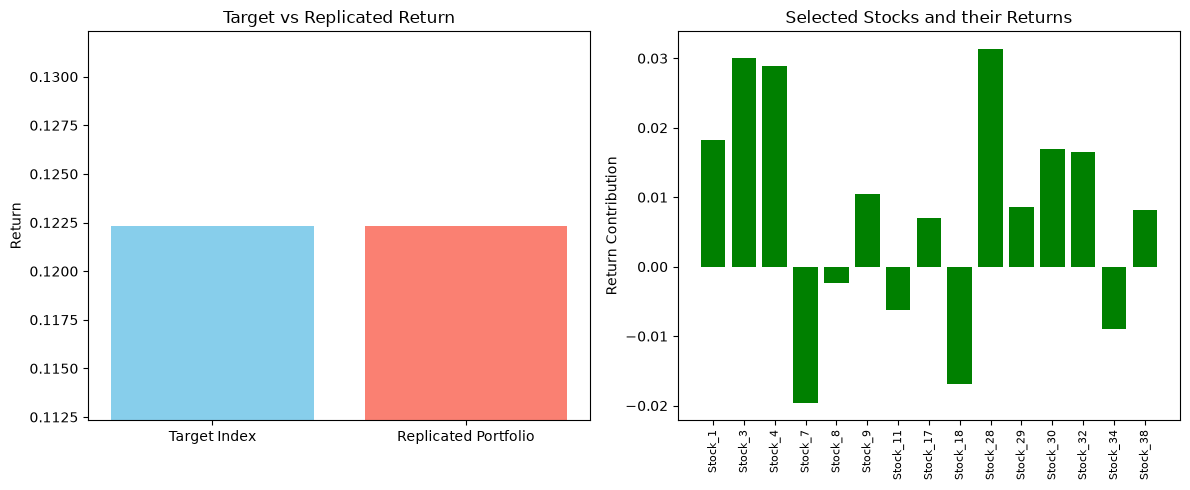

In [5]:
plt.figure(figsize=(12, 5))

# Plot 1: did we hit the benchmark? Target bar vs replicated-portfolio bar
plt.subplot(1, 2, 1)
labels = ['Target Index', 'Replicated Portfolio']
values = [R_TARGET, replicated_return]
colors = ['skyblue', 'salmon']
plt.bar(labels, values, color=colors)
plt.ylabel('Return')
plt.title('Target vs Replicated Return')
plt.ylim(min(values)-0.01, max(values)+0.01)

# Plot 2: which stocks were chosen and how much each contributes to the summed return
plt.subplot(1, 2, 2)
selected_names = df_stocks['Ticker'].iloc[selected_indices]
plt.bar(selected_names, selected_returns, color='green')
plt.xticks(rotation=90, fontsize=8)
plt.ylabel('Return Contribution')
plt.title('Selected Stocks and their Returns')

plt.tight_layout()
plt.show()

### Summary of the Lecture
1.  **Problem Transformation:** We successfully transformed a continuous-looking objective function into a discrete **QUBO** form by leveraging the property $x^2 = x$ for binary 
variables.
2.  **Complexity:** As the number of stocks ($N$) grows, the number of quadratic interactions grows at $O(N^2)$. Classical solvers struggle with high-cardinality constraints, 
whereas Quantum Annealers excel at navigating these "rugged" energy landscapes.
3.  **Limitations:** In this lecture, we used **Simulated Annealing**. A real **Quantum Annealer** (like D-Wave) uses quantum tunneling to escape local minima more efficiently 
than thermal fluctuations.

### Discussion Questions for Students
*   How would the QUBO change if we added a constraint that exactly $K$ stocks must be chosen? *(Hint: Add a penalty term $\lambda (\sum x_i - K)^2$)*.
*   How does transaction cost affect the quadratic terms of our matrix?
*   What are the implications of "Noise" in real Quantum Hardware on this financial calculation?



While **Quantum Annealing** (the previous section) is great for finding the global minimum of an energy landscape, **Gate-Based 
Quantum Computing** (like IBM's superconducting chips) uses unitary transformations and quantum gates to evolve a state toward the solution.

For optimization, the standard algorithm is **QAOA (Quantum Approximate Optimization Algorithm)**.

You should add these cells to your Jupyter Notebook after the "Simulated Annealing" section.

---

## Part 2: The Gate-Based Approach (Qiskit)

### 1. Transitioning from QUBO to Ising Hamiltonian
In the previous section, we worked with $x_i \in \{0, 1\}$. In a gate-based quantum computer, we work with qubits where the state is $|\psi\rangle$. To use qubits, we must map 
our binary variables to the **Pauli-Z operator** ($\sigma^z$).

The mapping is:
$$ x_i = \frac{I - Z_i}{2} $$

When we substitute this into our QUBO equation, the problem transforms from a quadratic polynomial of $x$ into an **Ising Hamiltonian** ($H_C$), which is a sum of Pauli-Z 
operators:
$$ H_C = \sum h_i Z_i + \sum J_{ij} Z_i Z_j $$

### 2. The QAOA Algorithm
QAOA is a variational algorithm. It consists of two alternating operators applied for $p$ layers:
1.  **Cost Hamiltonian ($H_C$):** Encodes the cost function (our index tracking error).
2.  **Mixer Hamiltonian ($H_B$):** Typically $\sum X_i$, which allows the quantum state to "tunnel" between different configurations of stocks.

The algorithm aims to find the optimal parameters $(\gamma, \beta)$ that minimize the expectation value: 
$$ \langle \psi(\gamma, \beta) | H_C | \psi(\gamma, \beta) \rangle $$


In [6]:
# %% Modernized Imports for Qiskit 1.x / 2.0+
import numpy as np
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.problems import QuadraticProgram

from qiskit.primitives import StatevectorSampler

print("Qiskit environment ready.")

# Build the SAME index-replication objective, but as a Qiskit QuadraticProgram instead of a raw matrix.
# Each binary variable x_i becomes one QUBIT, so n variables -> n qubits.
def solve_with_qiskit(returns, target_return):
    n = len(returns)
    qp = QuadraticProgram("IndexReplication")

    # One binary variable (one qubit) per stock
    for i in range(n):
        qp.binary_var(name=f'x_{i}')

    # linear_dict   -> the DIAGONAL coefficients (same r_i^2 - 2 R_target r_i as the matrix Q[i,i])
    # quadratic_dict-> the OFF-DIAGONAL couplings (same 2 r_i r_j as Q[i,j])
    linear_dict = {}
    quadratic_dict = {}
    for i in range(n):
        linear_dict[f'x_{i}'] = (returns[i]**2) - (2 * target_return * returns[i])
        for j in range(i + 1, n):
            quadratic_dict[(f'x_{i}', f'x_{j}')] = 2 * returns[i] * returns[j]

    qp.minimize(linear=linear_dict, quadratic=quadratic_dict)
    return qp

# Gate-based simulation cost grows exponentially with qubit count, so we use a TINY universe here.
N_QUBITS = 6
df_small, R_TARGET_SMALL = generate_market_data(N_QUBITS)
qp_problem = solve_with_qiskit(df_small['Return'].values, R_TARGET_SMALL)

print(f"\nConstructed Qiskit Quadratic Program for {N_QUBITS} qubits.")

# %%
# 3. Initialize the QAOA Solver Components
# StatevectorSampler = noiseless reference simulator (exact statevector, no shot noise)
sampler_instance = StatevectorSampler()

# COBYLA = the CLASSICAL optimizer in the hybrid loop; it tunes the QAOA angles (gamma, beta)
optimizer = COBYLA(maxiter=50)

# reps = p = number of cost+mixer layers; more layers = better approximation but harder to optimise
qaoa = QAOA(sampler=sampler_instance, optimizer=optimizer, reps=1)

# MinimumEigenOptimizer wraps QAOA so it can ingest a QuadraticProgram directly
optimizer_backend = MinimumEigenOptimizer(qaoa)

print("Starting QAOA execution on modern reference simulator...")
result = optimizer_backend.solve(qp_problem)

# result.x = the optimal 0/1 selection vector (one entry per qubit/stock)
print("\n--- QAOA Optimization Results ---")
print(f"Status: {result.status}")
print(f"Optimal Selection Vector: {result.x}")

Qiskit environment ready.

Constructed Qiskit Quadratic Program for 6 qubits.
Starting QAOA execution on modern reference simulator...


/home/p3p3/SUMMER_SCHOOL/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/p3p3/SUMMER_SCHOOL/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



--- QAOA Optimization Results ---
Status: OptimizationResultStatus.SUCCESS
Optimal Selection Vector: [1. 0. 0. 0. 1. 0.]


# Topic: Extending Index Replication to Multi-Period Optimization

In the single-period setup, we assumed a static snapshot where a portfolio is chosen once and held forever. However, real-world portfolio management spans across multiple consecutive time periods ($t = 1, 2, \dots, T$). 

When extending our optimization model into a multi-period framework, two major modifications occur:
1. **Time-Varying Parameters:** Returns and targets change at each time step.
2. **Inter-Temporal Coupling:** Choosing a stock in period $t$ depends on whether we held it in period $t-1$ due to **transaction costs (rebalancing penalties)**.

---

### 1. Variables and Notation
Let:
* $t$: The time period index, where $t \in \{1, \dots, T\}$.
* $r_{i, t}$: The expected return of stock $i$ during period $t$.
* $R_{\text{target}, t}$: The benchmark index's target return during period $t$.
* $x_{i, t} \in \{0, 1\}$: A binary decision variable where $1$ means we hold stock $i$ during period $t$, and $0$ means we do not.
* $C_i$: The transaction cost rate (penalty) associated with changing the allocation of stock $i$.

---

### 2. The Multi-Period Objective Function

Our global goal is to minimize both the **cumulative tracking error** across all periods and the **transaction costs** generated by rebalancing the portfolio between periods.

#### Component A: Cumulative Tracking Error
We sum the squared tracking errors across the entire time horizon:
$$f_{\text{tracking}}(x) = \sum_{t=1}^{T} \left( \sum_{i=1}^{n} r_{i, t} x_{i, t} - R_{\text{target}, t} \right)^2$$

#### Component B: Transaction/Rebalancing Costs
A transaction occurs for stock $i$ if its status changes between period $t-1$ and period $t$ (i.e., moving from $0 \rightarrow 1$ or $1 \rightarrow 0$). Mathematically, this change can be captured using the squared difference $(x_{i, t} - x_{i, t-1})^2$. 

Expanding the square:
$$(x_{i, t} - x_{i, t-1})^2 = x_{i, t}^2 - 2x_{i, t}x_{i, t-1} + x_{i, t-1}^2$$

Since $x$ is binary ($x^2 = x$), this simplifies to an expression perfectly suited for a quadratic optimizer:
$$(x_{i, t} - x_{i, t-1})^2 = x_{i, t} + x_{i, t-1} - 2x_{i, t}x_{i, t-1}$$

Summing over all assets and periods ($t \ge 2$), the total transaction penalty is:
$$f_{\text{transaction}}(x) = \sum_{t=2}^{T} \sum_{i=1}^{n} C_i (x_{i, t} + x_{i, t-1} - 2x_{i, t}x_{i, t-1})$$

#### The Combined Multi-Period Objective
Using a risk-appetite multiplier $\gamma$ to scale the importance of transaction costs, the final objective becomes:
$$\text{Minimize } F(x) = f_{\text{tracking}}(x) + \gamma \cdot f_{\text{transaction}}(x)$$

---

### 3. Mapping to Multi-Period QUBO Form

To solve this on a Quantum Annealer or via QAOA, we flatten our 2D variable grid $(i, t)$ into a single 1D binary vector of length $N \times T$:
$$\mathbf{x} = [x_{1,1}, x_{2,1}, \dots, x_{N,1}, \quad x_{1,2}, \dots, x_{N,2}, \quad \dots, \quad x_{1,T}, \dots, x_{N,T}]$$

When we fully expand the objective function, we can group the coefficients into three categories to fill our **QUBO Matrix ($Q$)**:

#### 1. Linear Diagonal Terms ($Q_{(i,t), (i,t)}$)
The diagonal elements represent the baseline cost of holding asset $i$ at time $t$. They combine the squared individual returns and target returns with transaction penalties:
* **For intermediate periods ($1 < t < T$):** The asset is penalized twice because it can transition from $t-1$ and into $t+1$.
  $$Q_{(i,t), (i,t)} = (r_{i,t}^2 - 2R_{\text{target},t}r_{i,t}) + 2\gamma C_i$$
* **For boundary periods ($t=1$ or $t=T$):** The asset is only penalized once.
  $$Q_{(i,t), (i,t)} = (r_{i,t}^2 - 2R_{\text{target},t}r_{i,t}) + \gamma C_i$$

#### 2. Intra-Period Quadratic Terms ($Q_{(i,t), (j,t)}$)
These capture the cross-asset asset correlations *within the exact same time period* ($i < j$). They remain identical to our single-period expansion:
$$Q_{(i,t), (j,t)} = 2 r_{i,t} r_{j,t}$$

#### 3. Inter-Period Quadratic Terms ($Q_{(i,t-1), (i,t)}$)
This is the new "quantum chain" interaction that links time steps together. The transaction cost introduces a **negative cross-term** between the same asset across adjacent time steps:
$$Q_{(i,t-1), (i,t)} = -2 \gamma C_i$$

> **Why is it negative?** If both $x_{i,t-1}=1$ and $x_{i,t}=1$, the negative coupling offsets the positive linear diagonal penalties added above. This lowers the overall energy of the system, mathematically encouraging the quantum state to avoid unnecessary trading.

In [7]:
def build_multi_period_qubo(returns_matrix, target_returns, transaction_cost, gamma=1.0):
    """
    Build the QUBO for the MULTI-PERIOD problem (tracking error + rebalancing cost).

    Parameters
    ----------
    returns_matrix : np.ndarray, shape (N_STOCKS, T_PERIODS)
        r_{i,t} = return of stock i during period t.
    target_returns : array-like, length T_PERIODS
        Benchmark target for each period.
    transaction_cost : float
        Penalty C_i charged whenever a holding flips on/off between periods.

    Variable layout
    ---------------
    There is one binary variable per (stock, period) pair -> N*T variables total,
    so the QUBO Q is square of size (N*T) x (N*T). We FLATTEN the 2-D (stock, period)
    grid into a single 1-D index via  get_idx(s, p) = p*N + s  (period-major order).
    """
    n_stocks, n_periods = returns_matrix.shape
    total_vars = n_stocks * n_periods               # N*T binary variables
    Q = np.zeros((total_vars, total_vars))          # -> Q is (N*T) x (N*T)

    # Map a (stock s, period p) pair to its flat row/column index in Q
    def get_idx(s, p):
        return p * n_stocks + s

    for t in range(n_periods):
        r_t = returns_matrix[:, t]                  # all stock returns for period t
        R_target_t = target_returns[t]

        # 1. INTRA-PERIOD block = ordinary single-period tracking error, repeated per period t.
        #    These touch only variables that share the same period t (a diagonal block of Q).
        for i in range(n_stocks):
            idx_i = get_idx(i, t)
            # DIAGONAL: linear tracking term for stock i in period t
            Q[idx_i, idx_i] += (r_t[i]**2) - (2 * R_target_t * r_t[i])
            # OFF-DIAGONAL within period t: pair coupling 2 r_i r_j (same as single-period case)
            for j in range(i + 1, n_stocks):
                idx_j = get_idx(j, t)
                Q[idx_i, idx_j] += 2 * r_t[i] * r_t[j]

        # 2. INTER-PERIOD coupling = transaction cost linking the SAME stock across adjacent periods.
        #    (x_{i,t} - x_{i,t-1})^2  =  x_{i,t} + x_{i,t-1} - 2 x_{i,t} x_{i,t-1}  for binaries.
        if t > 0:
            for i in range(n_stocks):
                idx_past = get_idx(i, t - 1)         # stock i in the previous period
                idx_curr = get_idx(i, t)            # stock i in the current period

                # The linear +x_{i,t} and +x_{i,t-1} parts land on the DIAGONAL
                Q[idx_past, idx_past] += gamma * transaction_cost
                Q[idx_curr, idx_curr] += gamma * transaction_cost

                # The -2 x_{i,t} x_{i,t-1} part is an OFF-DIAGONAL coupling between the two time copies.
                # It is NEGATIVE: keeping the holding unchanged (both 1) lowers energy -> discourages churn.
                Q[idx_past, idx_curr] += -2 * gamma * transaction_cost

    return Q

In [8]:
# 1. Generate Mock Multi-Period Market Data
def generate_multi_period_data(n_stocks=10, n_periods=3):
    np.random.seed(42)
    # returns_matrix[i, t] = return of stock i in period t  -> shape (N_STOCKS, T_PERIODS)
    returns_matrix = np.random.uniform(-0.02, 0.05, size=(n_stocks, n_periods))
    # One benchmark target per period -> length T_PERIODS
    target_returns = np.random.uniform(0.01, 0.03, size=n_periods)
    return returns_matrix, target_returns

# Dimensions: the QUBO will have N_STOCKS * T_PERIODS binary variables
N_STOCKS = 8      # stocks to choose from
T_PERIODS = 3     # time horizons (e.g. Q1, Q2, Q3)
TRANSACTION_COST = 0.005  # C_i: penalty per asset rebalance (0.5%)
GAMMA = 1.5       # weight scaling how strongly transaction costs matter vs tracking error

returns_mat, target_rets = generate_multi_period_data(N_STOCKS, T_PERIODS)

print("--- Multi-Period Market Context ---")
print(f"Target Benchmark Returns per Period: {target_rets}")
print(f"Asset Returns Matrix Shape (Stocks x Periods): {returns_mat.shape}\n")

--- Multi-Period Market Context ---
Target Benchmark Returns per Period: [0.0191214  0.02570352 0.01399348]
Asset Returns Matrix Shape (Stocks x Periods): (8, 3)



In [9]:
# Construct the multi-period optimization matrix (size N*T x N*T)
Q_multi = build_multi_period_qubo(returns_mat, target_rets, TRANSACTION_COST, gamma=GAMMA)
print(f"Multi-period QUBO Matrix constructed. Size: {Q_multi.shape} (N_STOCKS * T_PERIODS)")


# 3. Convert the dense matrix to the sampler's sparse dict {(i, j): weight} (upper triangle only)
qubo_dict = {}
total_dim = N_STOCKS * T_PERIODS          # number of binary variables = matrix dimension
for i in range(total_dim):
    for j in range(i, total_dim):
        if Q_multi[i, j] != 0:
            qubo_dict[(i, j)] = Q_multi[i, j]


# 4. Run Simulated Annealing over the full N*T variable problem
sampler = SimulatedAnnealingSampler()

print("Starting Multi-Period Annealing process...")
sampleset = sampler.sample_qubo(qubo_dict, num_reads=500)
best_sample = sampleset.first.sample      # dict {flat_index -> 0/1}


# 5. Decode the flat 1-D solution back into a 2-D (stock x period) holding schedule.
#    Inverse of get_idx: flat_idx = period*N_STOCKS + stock, so we undo it with divmod.
portfolio_schedule = np.zeros((N_STOCKS, T_PERIODS), dtype=int)
for flat_idx, binary_val in best_sample.items():
    period = flat_idx // N_STOCKS         # which time period this variable belonged to
    stock = flat_idx % N_STOCKS           # which stock
    portfolio_schedule[stock, period] = binary_val

# Per-period performance: compare the held basket's return to that period's benchmark
print("\n=== Multi-Period Optimization Breakdown ===")
for t in range(T_PERIODS):
    selected_indices = np.where(portfolio_schedule[:, t] == 1)[0]
    allocated_returns = returns_mat[selected_indices, t]
    replicated_return = np.sum(allocated_returns)
    tracking_error = abs(replicated_return - target_rets[t])

    print(f"\n[Period {t+1}]")
    print(f"  Target Return:     {target_rets[t]:.4f}")
    print(f"  Replicated Return: {replicated_return:.4f}")
    print(f"  Tracking Error:    {tracking_error:.4f}")
    print(f"  Selected Stocks:   {list(selected_indices)}")

# Turnover = how many holdings flipped between consecutive periods (what the cost term suppresses)
turnover_count = 0
for t in range(1, T_PERIODS):
    turnover_count += np.sum(np.abs(portfolio_schedule[:, t] - portfolio_schedule[:, t-1]))

print(f"\nTotal Multi-Period Trading Assets Exchanged: {turnover_count} position shifts.")

Multi-period QUBO Matrix constructed. Size: (24, 24) (N_STOCKS * T_PERIODS)
Starting Multi-Period Annealing process...

=== Multi-Period Optimization Breakdown ===

[Period 1]
  Target Return:     0.0191
  Replicated Return: 0.0223
  Tracking Error:    0.0032
  Selected Stocks:   [np.int64(2), np.int64(4)]

[Period 2]
  Target Return:     0.0257
  Replicated Return: 0.0355
  Tracking Error:    0.0098
  Selected Stocks:   [np.int64(2), np.int64(4)]

[Period 3]
  Target Return:     0.0140
  Replicated Return: 0.0148
  Tracking Error:    0.0008
  Selected Stocks:   [np.int64(2), np.int64(4)]

Total Multi-Period Trading Assets Exchanged: 0 position shifts.


# Part 3: Risk-Aware Index Replication (Adding a Variance Layer)

So far our objective only **matched the return** of the benchmark:
$$ f(x) = \left( \sum_i r_i x_i - R_{target} \right)^2 $$

But two portfolios can have the *same* expected return while having very
different **risk**. A professional tracker also wants the replicating
portfolio to be *stable* — i.e. to have low **variance**. This is the second
"layer" of the classic **mean–variance** framework (Markowitz).

### A second objective: portfolio variance
Given a covariance matrix $\Sigma$ estimated from the assets' **return series**,
the variance of the selected (equally-weighted) portfolio is the quadratic form
$$ \sigma_p^2(x) = \sum_i \sum_j \Sigma_{ij}\, x_i x_j
   = \sum_i \Sigma_{ii} x_i + 2\sum_{i<j} \Sigma_{ij}\, x_i x_j $$
(using $x_i^2 = x_i$ for binary variables).

### The combined objective
We add it to the tracking error with a **risk-aversion weight** $\lambda \ge 0$:
$$ F(x) = \underbrace{\left( \sum_i r_i x_i - R_{target}\right)^2}_{\text{track the index}}
        + \lambda \underbrace{\sum_i\sum_j \Sigma_{ij} x_i x_j}_{\text{control the risk}} $$

This is **still a QUBO** — the variance term only contributes to the same
linear/quadratic coefficients we already have:
$$ Q_{ii} \mathrel{+}= \lambda\,\Sigma_{ii}, \qquad Q_{ij} \mathrel{+}= 2\lambda\,\Sigma_{ij}\ \ (i<j) $$

> Sweeping $\lambda$ traces out a **risk / tracking-error frontier**:
> $\lambda=0$ recovers the original pure-replication problem; large $\lambda$
> sacrifices tracking accuracy for a lower-volatility portfolio.

In [10]:
# To add a VARIANCE term we need a covariance matrix, which requires a RETURN SERIES
# (many observations per stock), not just one scalar return per stock as before.
import numpy as np
import pandas as pd

def generate_market_data_with_series(n_stocks=30, n_obs=60, seed=4):
    """
    Returns
    -------
    df            : DataFrame (N rows) with 'Ticker' and the mean 'Return' per stock
    target_return : scalar benchmark = mean return of a random subset
    cov           : COVARIANCE matrix, shape (N x N) -> drives the variance term (Sigma)
    series        : raw observations, shape (n_obs x N) = the time series we estimate Sigma from
    """
    rng = np.random.default_rng(seed)

    mean_p = rng.uniform(-0.01, 0.04, n_stocks)   # per-stock average period return (length N)
    vol_p  = rng.uniform(0.02, 0.08, n_stocks)    # per-stock volatility (length N)

    # A single shared market factor injects genuine CO-movement, so the off-diagonal
    # covariances are non-zero (otherwise Sigma would be ~diagonal and uninteresting).
    factor = rng.normal(0, 0.03, n_obs)           # one common factor value per observation
    beta   = rng.uniform(0, 1.2, n_stocks)        # each stock's sensitivity to that factor
    idio   = rng.normal(0, 1, (n_obs, n_stocks)) * vol_p   # independent per-stock noise

    # series[t, i] = factor exposure + idiosyncratic noise  -> shape (n_obs x N)
    series = mean_p + np.outer(factor, beta) + idio

    mean_returns = series.mean(axis=0)            # average down the columns -> length-N vector r_i
    cov          = np.cov(series, rowvar=False)   # rowvar=False: columns are variables -> (N x N) Sigma

    # Reachable benchmark again: mean return of a random ~30% subset
    target_mask   = rng.binomial(1, 0.3, n_stocks)
    target_return = float(np.sum(mean_returns * target_mask))

    names = [f'Stock_{i}' for i in range(n_stocks)]
    df = pd.DataFrame({'Ticker': names, 'Return': mean_returns})
    return df, target_return, cov, series

N_STOCKS_RA = 30
df_ra, R_TARGET_RA, COV_RA, SERIES_RA = generate_market_data_with_series(N_STOCKS_RA)

print(f"Target Index Return : {R_TARGET_RA:.4f}")
print(f"Return series shape : {SERIES_RA.shape}  (observations x stocks)")
print(f"Covariance matrix   : {COV_RA.shape}  (N x N)")
df_ra.head()

Target Index Return : 0.1928
Return series shape : (60, 30)  (observations x stocks)
Covariance matrix   : (30, 30)  (N x N)


,Ticker,Return
0,Stock_0,0.036566
1,Stock_1,0.015978
2,Stock_2,0.047614
3,Stock_3,-0.003599
4,Stock_4,0.019616


In [11]:
def build_qubo_with_variance(mean_returns, target_return, cov, risk_lambda=1.0):
    """
    QUBO for the RISK-AWARE objective:

        F(x) = ( sum_i r_i x_i - R_target )^2   +   lambda * ( x^T Sigma x )
               \________ tracking error ________/        \___ portfolio variance ___/

    The variance term x^T Sigma x expands (with x_i^2 = x_i) to
        sum_i Sigma_ii x_i  +  2 sum_{i<j} Sigma_ij x_i x_j,
    so it just ADDS onto the existing tracking coefficients - the matrix stays N x N.
    """
    n = len(mean_returns)             # still one variable per stock -> Q is (N x N)
    Q = np.zeros((n, n))
    for i in range(n):
        # DIAGONAL = tracking-error linear term  +  lambda * Sigma_ii (asset i's OWN variance)
        Q[i, i] = (mean_returns[i]**2 - 2*target_return*mean_returns[i]) \
                  + risk_lambda * cov[i, i]
        for j in range(i + 1, n):
            # OFF-DIAGONAL = tracking pair term  +  lambda * 2*Sigma_ij (COVARIANCE between i and j)
            # Positive covariance raises energy -> the solver avoids bundling co-moving stocks.
            Q[i, j] = 2*mean_returns[i]*mean_returns[j] \
                      + risk_lambda * 2 * cov[i, j]
    return Q

# Sanity check: lambda=0 strips the variance layer and must reproduce the original pure-tracking QUBO
Q_check = build_qubo_with_variance(df_ra['Return'].values, R_TARGET_RA, COV_RA, risk_lambda=0.0)
print("Risk-aware QUBO builder ready. Shape:", Q_check.shape, "(N x N)")

Risk-aware QUBO builder ready. Shape: (30, 30) (N x N)


<>:2: SyntaxWarning: invalid escape sequence '\_'
<>:2: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_4133332/575765147.py:2: SyntaxWarning: invalid escape sequence '\_'
  """


In [12]:
# Sweep the risk-aversion weight lambda and watch tracking accuracy trade off against volatility.
from dwave.samplers import SimulatedAnnealingSampler

sampler = SimulatedAnnealingSampler()

def qubo_to_dict(Q):
    # Dense (N x N) matrix -> sparse upper-triangle dict {(i,j): weight} the sampler expects
    n = Q.shape[0]
    return {(i, j): Q[i, j] for i in range(n) for j in range(i, n) if Q[i, j] != 0}

def solve_qubo(Q, num_reads=300):
    sampleset = sampler.sample_qubo(qubo_to_dict(Q), num_reads=num_reads)
    s = sampleset.first.sample
    # Rebuild a clean 0/1 vector in index order (sampler dict keys may be unordered)
    return np.array([s[i] for i in range(Q.shape[0])])

mean_r = df_ra['Return'].values
lambdas = [0.0, 0.5, 1.0, 3.0, 10.0]      # lambda=0 -> pure tracking; larger -> more risk-averse
frontier = []

print(f"{'lambda':>7} | {'#stocks':>7} | {'repl.ret':>9} | {'track.err':>9} | {'volatility':>10}")
print("-" * 56)
for lam in lambdas:
    x = solve_qubo(build_qubo_with_variance(mean_r, R_TARGET_RA, COV_RA, lam))
    repl   = float(mean_r @ x)            # portfolio return = r . x
    var    = float(x @ COV_RA @ x)        # portfolio variance = x^T Sigma x (quadratic form)
    vol    = np.sqrt(max(var, 0.0))       # volatility = sqrt(variance)
    track  = abs(repl - R_TARGET_RA)      # tracking error
    frontier.append((lam, int(x.sum()), repl, track, vol))
    print(f"{lam:7.1f} | {int(x.sum()):7d} | {repl:9.4f} | {track:9.4f} | {vol:10.4f}")

print("\nNote: as lambda grows, volatility falls but tracking error rises.")

 lambda | #stocks |  repl.ret | track.err | volatility
--------------------------------------------------------
    0.0 |      13 |    0.1928 |    0.0000 |     0.3219
    0.5 |       5 |    0.1697 |    0.0231 |     0.1080
    1.0 |       4 |    0.1331 |    0.0596 |     0.0841
    3.0 |       3 |    0.0948 |    0.0979 |     0.0703
   10.0 |       1 |    0.0390 |    0.1538 |     0.0339

Note: as lambda grows, volatility falls but tracking error rises.


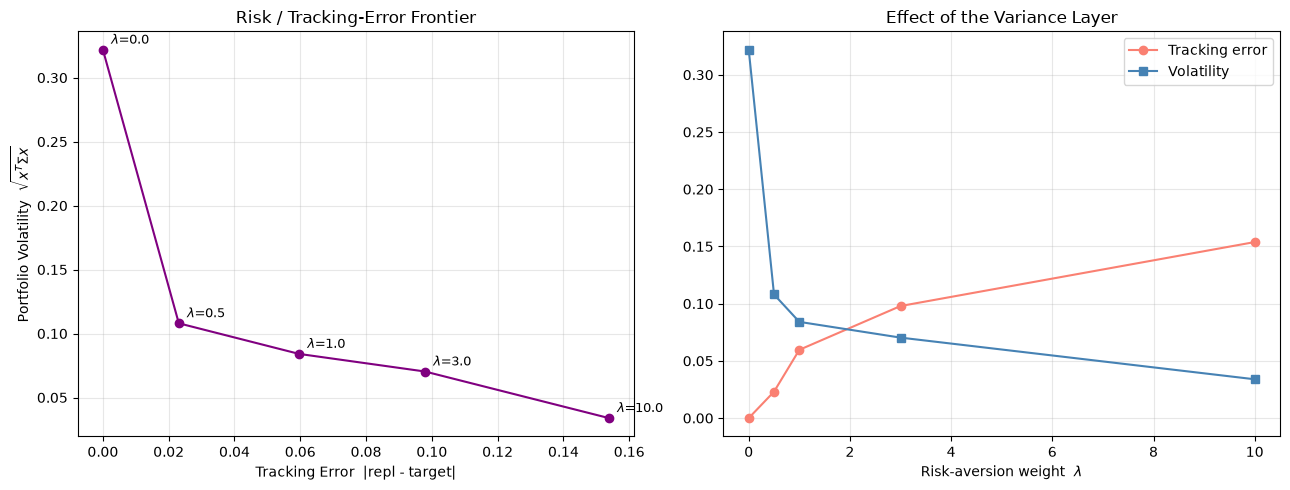

In [13]:
# Visualise the risk / tracking-error trade-off frontier
import matplotlib.pyplot as plt

lams   = [f[0] for f in frontier]
tracks = [f[3] for f in frontier]
vols   = [f[4] for f in frontier]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Left: the frontier (each point is a different lambda)
ax[0].plot(tracks, vols, 'o-', color='purple')
for lam, _, _, t, v in frontier:
    ax[0].annotate(f"$\\lambda$={lam}", (t, v), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax[0].set_xlabel('Tracking Error  |repl - target|')
ax[0].set_ylabel('Portfolio Volatility  $\\sqrt{x^T \\Sigma x}$')
ax[0].set_title('Risk / Tracking-Error Frontier')
ax[0].grid(alpha=0.3)

# Right: how each metric moves with lambda
ax[1].plot(lams, tracks, 'o-', label='Tracking error', color='salmon')
ax[1].plot(lams, vols,   's-', label='Volatility',     color='steelblue')
ax[1].set_xlabel('Risk-aversion weight  $\\lambda$')
ax[1].set_title('Effect of the Variance Layer')
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 4 (New Task): Min-Variance Portfolio from **Non-Correlated** Assets

The previous parts always needed a *benchmark* to track. We now switch to a
**pure risk problem**: with no return target at all, *which subset of assets is
the most diversified?* Intuitively we want to **search for assets whose return
series are not correlated** — combining un-correlated assets is what drives
portfolio variance down (the only free lunch in finance).

### Step 1 — Discover correlation structure from the return series
For each pair of assets we estimate the covariance $\Sigma_{ij}$ (and correlation
$\rho_{ij}$) directly from their historical return series. Highly correlated
assets move together and add little diversification; we want the optimiser to
**avoid bundling correlated names together**.

### Step 2 — A cardinality-constrained min-variance QUBO
We pick **exactly $K$** assets that minimise total portfolio variance:
$$ \min_{x\in\{0,1\}^n}\ \sum_i\sum_j \Sigma_{ij}x_ix_j
   \quad\text{s.t.}\quad \sum_i x_i = K $$

The equality constraint is folded into the objective with a penalty $P$:
$$ F(x) = \sum_i\sum_j \Sigma_{ij}x_ix_j \;+\; P\Big(\sum_i x_i - K\Big)^2 $$

Expanding the penalty $\big((\sum x_i)^2 = \sum x_i + 2\sum_{i<j}x_ix_j\big)$ gives a
clean QUBO:
$$ Q_{ii} = \Sigma_{ii} + P(1 - 2K), \qquad Q_{ij} = 2\Sigma_{ij} + 2P\ \ (i<j) $$

Because the off-diagonal $2\Sigma_{ij}$ terms *penalise selecting correlated
pairs together*, the energy minimum naturally favours a **mutually
un-correlated basket** — exactly the diversification we are hunting for.
We solve it both on the **annealer (SA proxy)** and with **QAOA**.

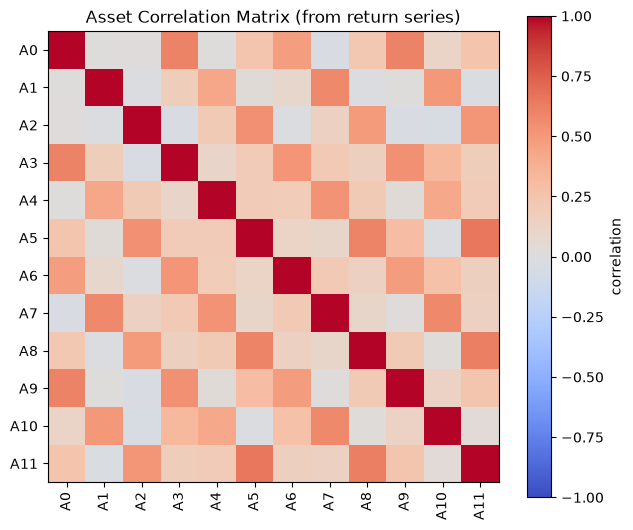

In [14]:
# Step 1: Build an asset universe with deliberate correlation CLUSTERS via a hidden
# factor model, then recover that structure PURELY from the simulated return series.
import numpy as np

def generate_correlated_universe(n_assets=12, n_obs=252, n_factors=3, seed=7):
    """
    Factor model: each asset loads mainly on ONE of n_factors latent drivers, so
    assets sharing a factor end up correlated while assets on different factors are
    nearly independent. Returns the (n_obs x n_assets) return series.
    """
    rng = np.random.default_rng(seed)
    factors  = rng.normal(0, 0.012, (n_obs, n_factors))   # latent drivers: (obs x n_factors)
    loadings = np.zeros((n_assets, n_factors))            # how strongly each asset tracks each factor
    for a in range(n_assets):
        f = a % n_factors                                 # assign asset a to factor f (round-robin -> clusters)
        loadings[a, f] = rng.uniform(0.8, 1.4)            # strong primary loading
        if rng.random() < 0.3:                            # sometimes a weak secondary loading
            loadings[a, (f + 1) % n_factors] = rng.uniform(0.2, 0.5)
    idio = rng.normal(0, 0.012, (n_obs, n_assets))        # per-asset idiosyncratic noise
    # returns[t, a] = sum over factors of (factor_t . loading_a) + noise -> (obs x n_assets)
    returns = factors @ loadings.T + idio
    return returns

N_ASSETS = 12
R_SERIES = generate_correlated_universe(N_ASSETS)         # raw series: (n_obs x N_ASSETS)
COV_MV   = np.cov(R_SERIES, rowvar=False)                 # covariance Sigma: (N x N) -> objective matrix
CORR_MV  = np.corrcoef(R_SERIES, rowvar=False)            # correlation: (N x N) -> only for inspection/plots
asset_names = [f'A{i}' for i in range(N_ASSETS)]

# Heatmap of the correlation matrix we are about to mine for mutually un-correlated assets.
# Red blocks = correlated clusters; blue/white = low correlation (the diversifiers we want).
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(CORR_MV, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(N_ASSETS)); ax.set_xticklabels(asset_names, rotation=90)
ax.set_yticks(range(N_ASSETS)); ax.set_yticklabels(asset_names)
ax.set_title('Asset Correlation Matrix (from return series)')
plt.colorbar(im, label='correlation'); plt.tight_layout(); plt.show()

In [15]:
# Step 2: QUBO builders for the cardinality-constrained MIN-VARIANCE problem.
def build_min_variance_qubo(cov, k, penalty):
    """
    Encode:   minimise  x^T Sigma x   subject to   sum_i x_i = k

    The equality constraint is folded into the objective with a quadratic penalty
        penalty * ( sum_i x_i - k )^2 ,
    which expands (binary x) to  penalty*(1-2k) * sum_i x_i  +  2*penalty * sum_{i<j} x_i x_j  + const.
    Adding that to the variance gives the QUBO entries below. Q is (N x N).
    """
    n = cov.shape[0]
    Q = np.zeros((n, n))
    for i in range(n):
        # DIAGONAL = asset i's own variance Sigma_ii  +  the linear part of the cardinality penalty
        Q[i, i] = cov[i, i] + penalty * (1 - 2 * k)
        for j in range(i + 1, n):
            # OFF-DIAGONAL = 2*covariance (penalises correlated pairs)  +  2*penalty (constraint coupling)
            Q[i, j] = 2 * cov[i, j] + 2 * penalty
    return Q

def qubo_to_quadratic_program(Q, name="MinVariance"):
    """Convert a dense upper-triangular QUBO (N x N) into a Qiskit QuadraticProgram (N qubits)."""
    from qiskit_optimization.problems import QuadraticProgram
    n = Q.shape[0]
    qp = QuadraticProgram(name)
    for i in range(n):
        qp.binary_var(name=f'x_{i}')                     # one qubit per asset
    linear    = {f'x_{i}': float(Q[i, i]) for i in range(n)}                        # diagonal -> linear
    quadratic = {(f'x_{i}', f'x_{j}'): float(Q[i, j])                               # off-diagonal -> quadratic
                 for i in range(n) for j in range(i + 1, n) if Q[i, j] != 0}
    qp.minimize(linear=linear, quadratic=quadratic)
    return qp

K = 4                                         # how many assets the basket must contain (cardinality)
# Penalty must dominate the tiny covariance magnitudes so the constraint sum(x)=K is actually enforced;
# scaling to the largest covariance entry is a robust rule of thumb.
PENALTY = 20 * np.max(np.abs(COV_MV))
Q_MV = build_min_variance_qubo(COV_MV, K, PENALTY)
print(f"Min-variance QUBO ready: shape {Q_MV.shape}, K={K}, penalty={PENALTY:.5f}")

Min-variance QUBO ready: shape (12, 12), K=4, penalty=0.00870


In [16]:
# Step 3a: Solve on the Simulated Annealer (our Quantum-Annealer proxy), full N_ASSETS universe.
from dwave.samplers import SimulatedAnnealingSampler
sampler = SimulatedAnnealingSampler()

def qubo_to_dict(Q):
    # Dense (N x N) -> sparse upper-triangle dict for the sampler
    n = Q.shape[0]
    return {(i, j): Q[i, j] for i in range(n) for j in range(i, n) if Q[i, j] != 0}

sampleset = sampler.sample_qubo(qubo_to_dict(Q_MV), num_reads=500)
x_anneal  = np.array([sampleset.first.sample[i] for i in range(N_ASSETS)])   # 0/1 vector, length N
selected  = np.where(x_anneal == 1)[0]                                       # indices of chosen assets

def avg_pairwise_corr(idx):
    # Mean of the upper-triangle correlations among the selected assets = how diversified the basket is
    if len(idx) < 2:
        return float('nan')
    sub = CORR_MV[np.ix_(idx, idx)]          # pull out the (k x k) sub-correlation block
    iu  = np.triu_indices(len(idx), 1)       # upper-triangle (exclude the diagonal of 1s)
    return float(sub[iu].mean())

# Baseline: average pairwise correlation of many RANDOM K-asset baskets, to prove the optimiser does better
rng = np.random.default_rng(0)
rand_corr = np.mean([avg_pairwise_corr(rng.choice(N_ASSETS, K, replace=False))
                     for _ in range(2000)])

print("--- Annealer Min-Variance Result ---")
print(f"Selected assets        : {[asset_names[i] for i in selected]}  (#={len(selected)})")
print(f"Portfolio variance     : {float(x_anneal @ COV_MV @ x_anneal):.6f}")   # x^T Sigma x
print(f"Avg pairwise corr (sel): {avg_pairwise_corr(selected):.4f}")
print(f"Avg pairwise corr (rnd): {rand_corr:.4f}   <- random K-baskets baseline")
print("\nThe optimiser picks a basket far LESS correlated than a random selection.")

--- Annealer Min-Variance Result ---
Selected assets        : ['A1', 'A2', 'A6', 'A9']  (#=4)
Portfolio variance     : 0.001415
Avg pairwise corr (sel): 0.0832
Avg pairwise corr (rnd): 0.2280   <- random K-baskets baseline

The optimiser picks a basket far LESS correlated than a random selection.


In [17]:
# Step 3b: Solve with QAOA (gate-based). State-vector simulation grows exponentially
# with qubit count, so -- as the lecture's comparison table notes -- QAOA is run on a
# SMALLER sub-universe. We take the first 6 assets and solve the identical min-variance
# problem on BOTH the annealer and QAOA for a fair head-to-head, while Step 3a above
# handled the full 12-asset universe.
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit.primitives import StatevectorSampler

SUB = 6                       # gate-based sub-universe size = qubit count (keep small!)
K_SUB = 2                     # pick 2 of the 6 assets
cov_sub  = COV_MV[:SUB, :SUB]     # top-left (6 x 6) block of the covariance matrix
corr_sub = CORR_MV[:SUB, :SUB]    # matching (6 x 6) correlation block
names_sub = asset_names[:SUB]
penalty_sub = 20 * np.max(np.abs(cov_sub))            # same penalty rule, scaled to the sub-problem
Q_sub = build_min_variance_qubo(cov_sub, K_SUB, penalty_sub)   # (6 x 6) QUBO

def avg_pairwise_corr_sub(idx):
    if len(idx) < 2:
        return float('nan')
    sub = corr_sub[np.ix_(idx, idx)]
    iu = np.triu_indices(len(idx), 1)
    return float(sub[iu].mean())

# --- Annealer on the sub-problem (reference answer to compare QAOA against) ---
ss_sub = sampler.sample_qubo(qubo_to_dict(Q_sub), num_reads=500)
x_sub_anneal = np.array([ss_sub.first.sample[i] for i in range(SUB)])
sel_sub_anneal = np.where(x_sub_anneal == 1)[0]

# --- QAOA on the SAME (6 x 6) sub-problem ---
qp_sub = qubo_to_quadratic_program(Q_sub, "MinVarianceSub")   # 6-qubit QuadraticProgram
qaoa = QAOA(sampler=StatevectorSampler(), optimizer=COBYLA(maxiter=50), reps=1)
print(f"Running QAOA on a {SUB}-qubit min-variance instance...")
res_qaoa = MinimumEigenOptimizer(qaoa).solve(qp_sub)

x_qaoa = np.array([int(round(v)) for v in res_qaoa.x])        # 0/1 selection from QAOA
sel_qaoa = np.where(x_qaoa == 1)[0]

print(f"\n--- {SUB}-asset Min-Variance: Annealer vs QAOA ---")
print(f"Annealer selection : {[names_sub[i] for i in sel_sub_anneal]}  "
      f"var={float(x_sub_anneal @ cov_sub @ x_sub_anneal):.6f}  "
      f"corr={avg_pairwise_corr_sub(sel_sub_anneal):.4f}")
print(f"QAOA selection     : {[names_sub[i] for i in sel_qaoa]}  "
      f"var={float(x_qaoa @ cov_sub @ x_qaoa):.6f}  "
      f"corr={avg_pairwise_corr_sub(sel_qaoa):.4f}")
print(f"QAOA status        : {res_qaoa.status}")
print("\nBoth paradigms converge on the same low-variance, low-correlation pair.")

Running QAOA on a 6-qubit min-variance instance...


/home/p3p3/SUMMER_SCHOOL/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/p3p3/SUMMER_SCHOOL/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



--- 6-asset Min-Variance: Annealer vs QAOA ---
Annealer selection : ['A1', 'A2']  var=0.000572  corr=-0.0197
QAOA selection     : ['A1', 'A2']  var=0.000572  corr=-0.0197
QAOA status        : OptimizationResultStatus.SUCCESS

Both paradigms converge on the same low-variance, low-correlation pair.


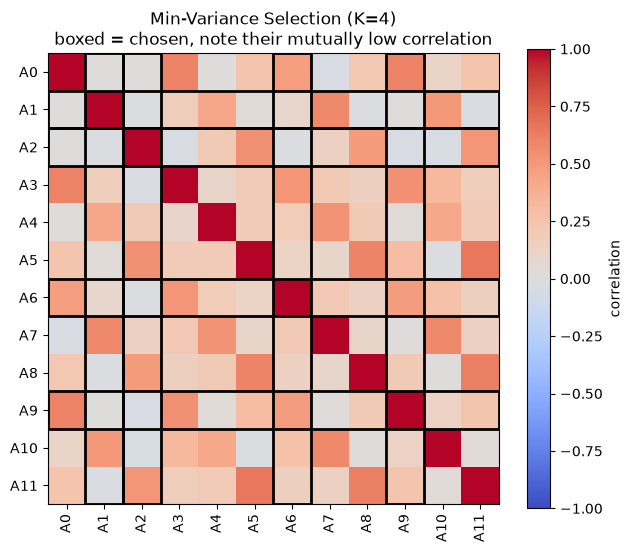

In [18]:
# Step 4: Visualise WHICH assets the annealer chose, on top of the correlation heatmap.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(CORR_MV, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(N_ASSETS)); ax.set_xticklabels(asset_names, rotation=90)
ax.set_yticks(range(N_ASSETS)); ax.set_yticklabels(asset_names)

# Draw a full row + column box around each selected asset. Where two selected rows/cols
# intersect you can read their mutual correlation - it should be pale (low), i.e. diversified.
for i in selected:
    ax.add_patch(plt.Rectangle((i-0.5, -0.5), 1, N_ASSETS, fill=False, edgecolor='black', lw=2))
    ax.add_patch(plt.Rectangle((-0.5, i-0.5), N_ASSETS, 1, fill=False, edgecolor='black', lw=2))

ax.set_title(f'Min-Variance Selection (K={K})\nboxed = chosen, note their mutually low correlation')
plt.colorbar(im, label='correlation'); plt.tight_layout(); plt.show()

### Summary of Parts 3 & 4
1. **Variance layer (Part 3):** adding $\lambda\,x^\top\Sigma x$ to the tracking
   objective keeps the problem a QUBO yet lets the annealer trade a little
   tracking accuracy for substantially lower volatility — a tunable
   **risk / tracking-error frontier**.
2. **Min-variance / diversification (Part 4):** with **no** return target, a
   cardinality-constrained min-variance QUBO *automatically* surfaces a basket of
   **mutually un-correlated assets**, because correlated pairs raise the energy
   through the $2\Sigma_{ij}$ couplings. Solved identically on the annealer and QAOA.

### Discussion Questions
* How sensitive is the chosen basket to the penalty weight $P$? What happens if $P$ is too small?
* The variance is estimated from a finite return series — how does estimation
  noise in $\Sigma$ affect the QUBO solution (and would more qubits help)?
* Could you combine *all three* layers — return matching **+** variance **+**
  cardinality — into a single QUBO? Write down its $Q_{ii}$ and $Q_{ij}$.